**PROJECT**

A ride-sharing company wants to implement a dynamic pricing strategy to optimize fares based on real-time market conditions. The company only uses ride duration to decide ride fares currently. The company aims to leverage data-driven techniques to analyze historical data and develop a predictive model that can dynamically adjust prices in response to changing factors.

The dataset containing historical ride data has been provided. It includes features such as the number of riders, number of drivers, location category, customer loyalty status, number of past rides, average ratings, time of booking, vehicle type, expected ride duration, and historical cost of the rides.

Your goal is to build a dynamic pricing model that incorporates the provided features to predict optimal fares for rides in real-time. The model must consider factors such as demand patterns and supply availability.

https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset/data

----------------------------------------------------------------------------------------------------------------
**STEP 1: IMPORT LIBRARIES**

In [1]:
#let's start importing the first libraries we'll need to use
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#read the csv and see at least the very first rows to get an idea of it
dp = pd.read_csv('dynamic_pricing.csv')
dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [6]:
dp["is_peak_hours"] = np.where(dp["Time_of_Booking"]=="Morning",1,
                               np.where(dp["Time_of_Booking"]=="Afternoon",1,
                                        np.where(dp["Time_of_Booking"]=="Evening",0,0)))

In [7]:
# d_s_ratio = Demand / Supply
dp["d_s_ratio"] = round(dp["Number_of_Riders"]/dp["Number_of_Drivers"], 2)

In [8]:
dp.dtypes

Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category           object
Customer_Loyalty_Status     object
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking             object
Vehicle_Type                object
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
is_peak_hours                int64
d_s_ratio                  float64
dtype: object

Notes: Number_of_Riders is the demand and Number_of_Drivers is the supply 

Let's see first if there are some missing values

In [9]:
dp.isna().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
is_peak_hours              0
d_s_ratio                  0
dtype: int64

In [10]:
dp[['Number_of_Riders','Number_of_Drivers','Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration','Historical_Cost_of_Ride','d_s_ratio']].describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride,d_s_ratio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623,3.235270
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756,2.533629
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449,1.110000
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202,1.660000
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426,2.360000
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504,3.800000
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419,17.600000


---------------------------------------------------------------------------------------------------------------
**STEP 2: EDA**

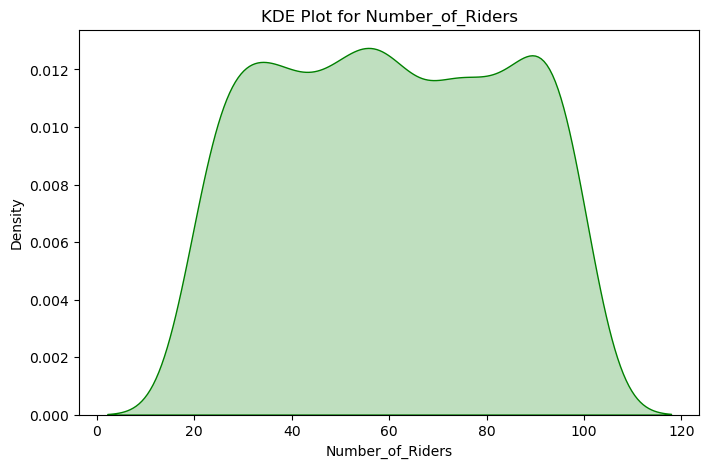

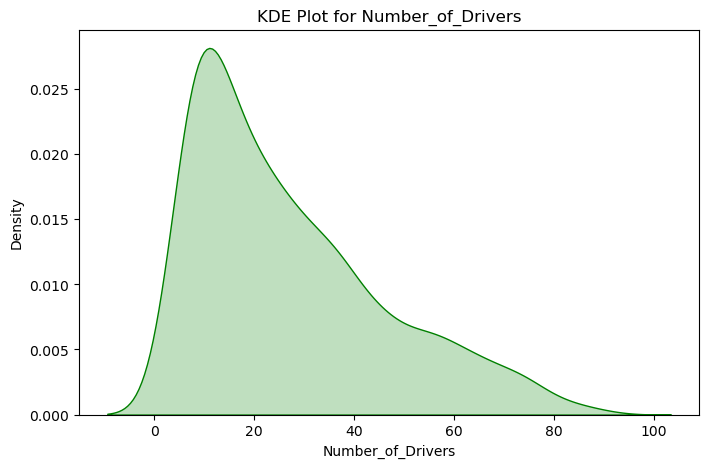

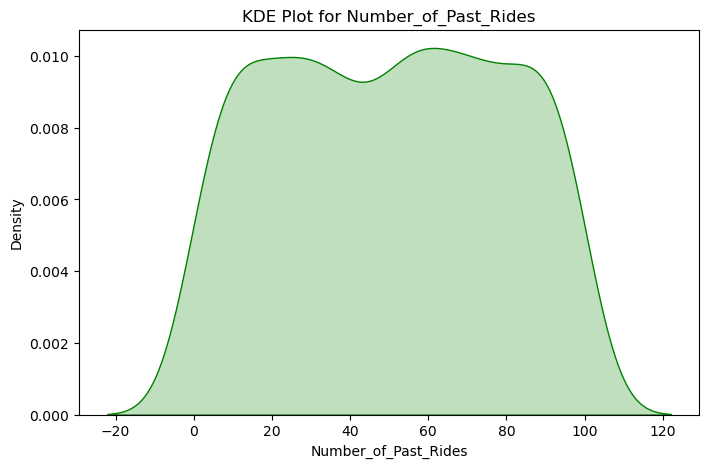

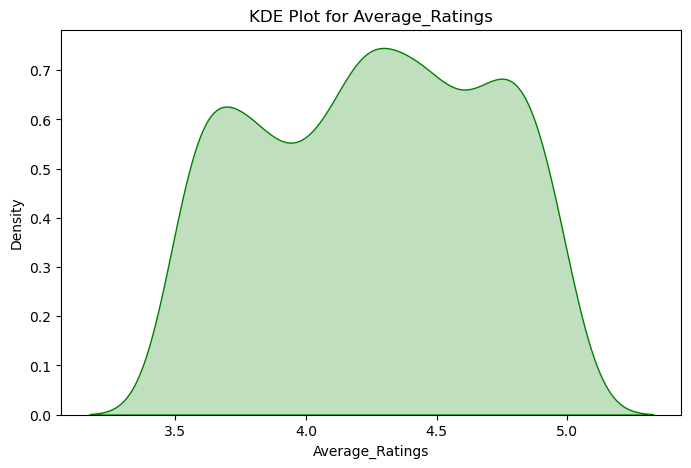

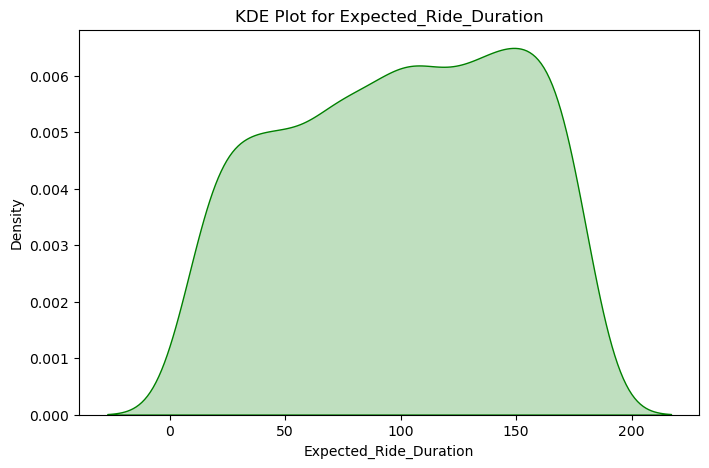

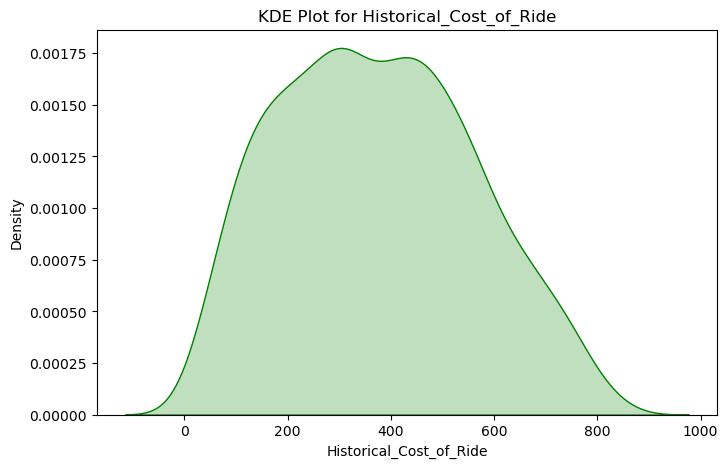

In [11]:
col=['Number_of_Riders','Number_of_Drivers','Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration','Historical_Cost_of_Ride']
for col in col:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot
    sns.kdeplot(dp[col], color='green', fill=True)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()  # Display the plot and close it before the next one

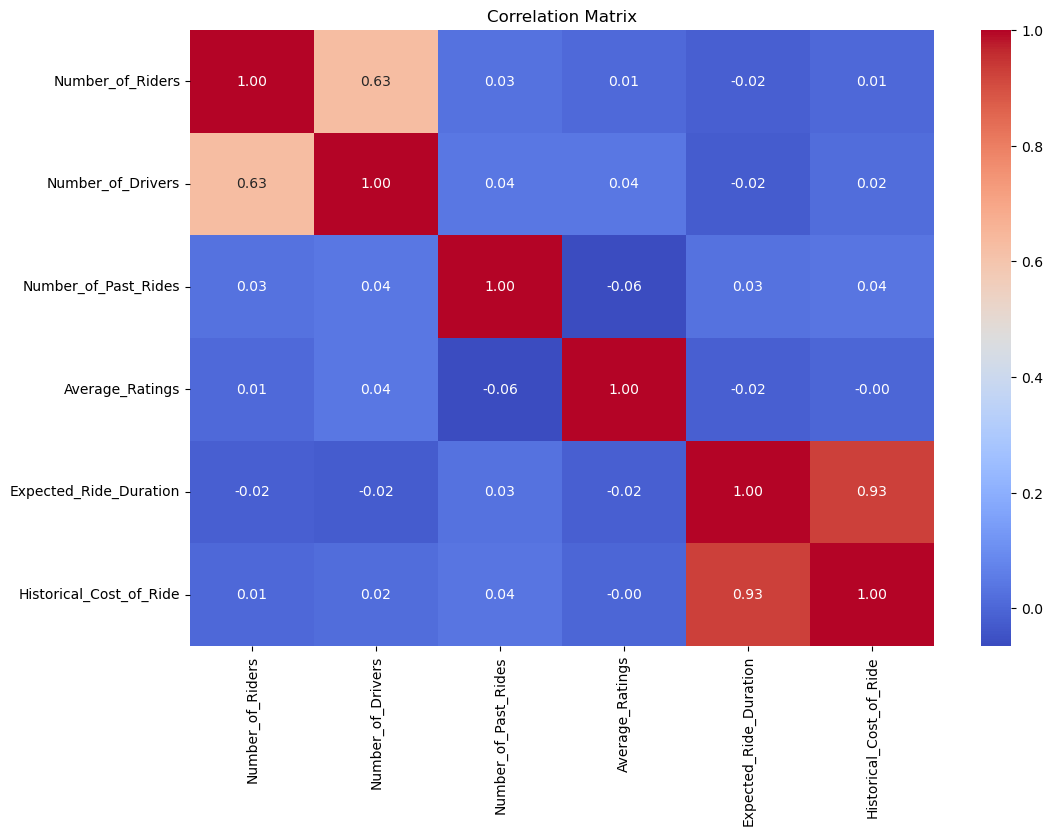

In [38]:
#let's see the correlation between the variables
col=['Number_of_Riders','Number_of_Drivers','Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration','Historical_Cost_of_Ride']
corr_matrix = dp[col].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Plots


<Figure size 2000x1500 with 0 Axes>

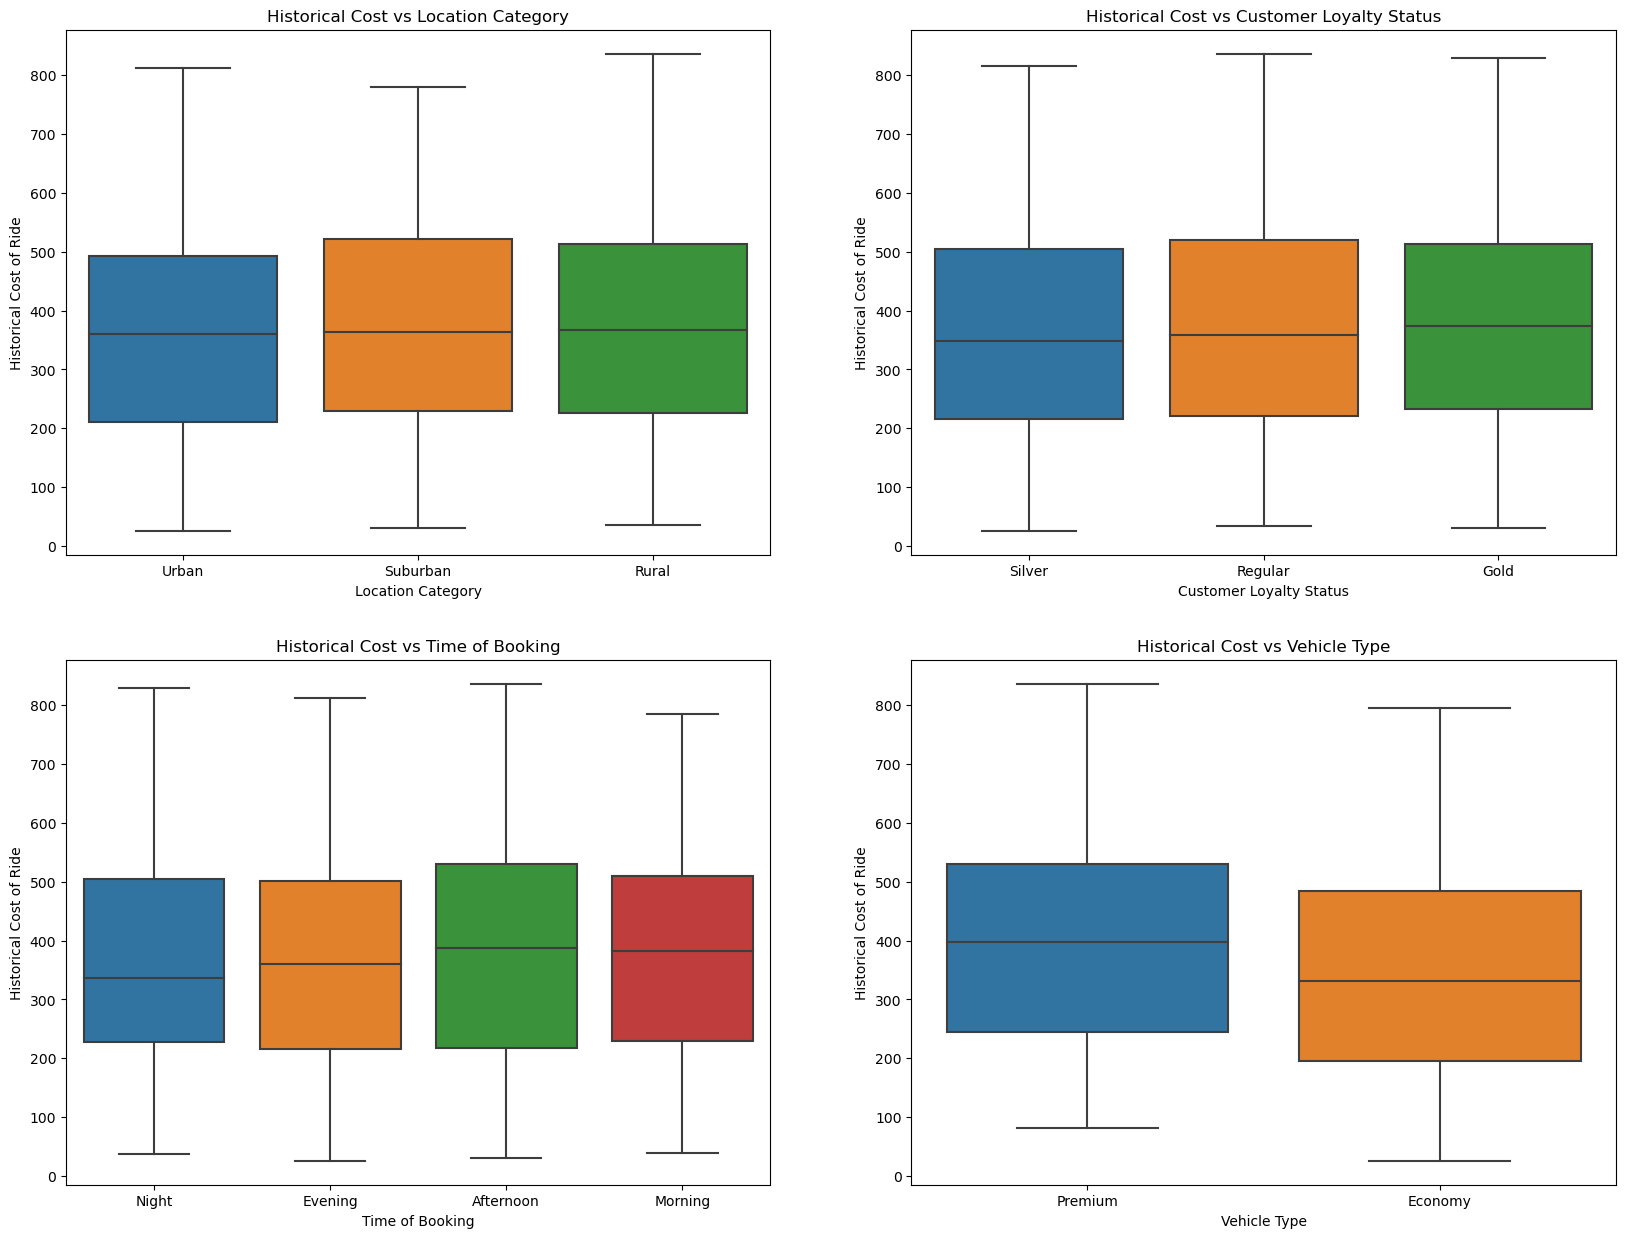

In [12]:
plt.figure(figsize=(20, 15))
fig, axs = plt.subplots(2, 2, figsize=(20, 15))

# Plot 1: Historical Cost vs Location Category
sns.boxplot(x='Location_Category', y='Historical_Cost_of_Ride', data=dp, ax=axs[0, 0])
axs[0, 0].set_title('Historical Cost vs Location Category')
axs[0, 0].set_xlabel('Location Category')
axs[0, 0].set_ylabel('Historical Cost of Ride')

# Plot 2: Historical Cost vs Customer Loyalty Status
sns.boxplot(x='Customer_Loyalty_Status', y='Historical_Cost_of_Ride', data=dp, ax=axs[0, 1])
axs[0, 1].set_title('Historical Cost vs Customer Loyalty Status')
axs[0, 1].set_xlabel('Customer Loyalty Status')
axs[0, 1].set_ylabel('Historical Cost of Ride')

# Plot 3: Historical Cost vs Time of Booking
sns.boxplot(x='Time_of_Booking', y='Historical_Cost_of_Ride', data=dp, ax=axs[1, 0])
axs[1, 0].set_title('Historical Cost vs Time of Booking')
axs[1, 0].set_xlabel('Time of Booking')
axs[1, 0].set_ylabel('Historical Cost of Ride')

# Plot 4: Historical Cost vs Vehicle Type
sns.boxplot(x='Vehicle_Type', y='Historical_Cost_of_Ride', data=dp, ax=axs[1, 1])
axs[1, 1].set_title('Historical Cost vs Vehicle Type')
axs[1, 1].set_xlabel('Vehicle Type')
axs[1, 1].set_ylabel('Historical Cost of Ride')

print("Plots")

------------------------------------------------------------------------------------------------------------------
**STEP 3: DEMAND & SUPPLY ANALYSIS**

In [13]:
dp["demand_class"] = np.where(dp["Number_of_Riders"]>np.percentile(dp["Number_of_Riders"], 75), 
                               "High_demand", np.where(dp["Number_of_Riders"]<np.percentile(dp["Number_of_Riders"], 25), 
                               "Low_demand", "Medium_demand"))

dp["supply_class"] = np.where(dp["Number_of_Drivers"]>np.percentile(dp["Number_of_Drivers"], 75), 
                               "High_supply", np.where(dp["Number_of_Drivers"]<np.percentile(dp["Number_of_Drivers"], 25), 
                               "Low_supply", "Medium_supply"))

dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,is_peak_hours,d_s_ratio,demand_class,supply_class
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0,2.00,High_demand,High_supply
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0,1.49,Medium_demand,High_supply
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1,1.35,Medium_demand,Medium_supply
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,1,3.18,High_demand,Medium_supply
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,1,3.55,Medium_demand,Medium_supply


In [14]:
dp["demand_metric"] = np.where(dp["demand_class"]=="High_demand", 
                               dp["Number_of_Riders"] / np.percentile(dp["Number_of_Riders"], 75),
                               np.where(dp["demand_class"]=="Medium_demand", 
                               dp["Number_of_Riders"] / np.percentile(dp["Number_of_Riders"], 50),
                                dp["Number_of_Riders"] / np.percentile(dp["Number_of_Riders"], 25)))

dp["supply_metric"] = np.where(dp["supply_class"]=="High_supply", 
                               dp["Number_of_Drivers"] / np.percentile(dp["Number_of_Drivers"], 75),
                               np.where(dp["supply_class"]=="Medium_supply", 
                               dp["Number_of_Drivers"] / np.percentile(dp["Number_of_Drivers"], 50),
                               dp["Number_of_Drivers"] / np.percentile(dp["Number_of_Drivers"], 25)))

dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,is_peak_hours,d_s_ratio,demand_class,supply_class,demand_metric,supply_metric
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0,2.00,High_demand,High_supply,1.111111,1.184211
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0,1.49,Medium_demand,High_supply,0.966667,1.026316
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1,1.35,Medium_demand,Medium_supply,0.700000,1.409091
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,1,3.18,High_demand,Medium_supply,1.098765,1.272727
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,1,3.55,Medium_demand,Medium_supply,1.300000,1.000000


In [16]:
dp["d_s_ratio"] = dp["demand_metric"]/dp["supply_metric"]

In [17]:
dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,is_peak_hours,d_s_ratio,demand_class,supply_class,demand_metric,supply_metric
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0,0.938272,High_demand,High_supply,1.111111,1.184211
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0,0.941880,Medium_demand,High_supply,0.966667,1.026316
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1,0.496774,Medium_demand,Medium_supply,0.700000,1.409091
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,1,0.863316,High_demand,Medium_supply,1.098765,1.272727
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,1,1.300000,Medium_demand,Medium_supply,1.300000,1.000000


We need to establish a range. For example:

– If the d_s_ratio is below 0.75, it means that demand is lower than supply, and the price should be decreased to encourage demand.

– If the d_s_ratio is between 0.75 and 1.5, it means that demand and supply are roughly balanced, and the price should be kept unchanged.

– If the d_s_ratio exceeds 1.5, it means that demand is higher than supply, and the price should be increased.

In [18]:
# Set cutoff values for high and low demand situations
upper_bound = 1.10  # High demand, low supply (Demand > Supply)
lower_bound = 0.90   # Low demand, high supply (Supply > Demand)


# Define correction metric based on demand-supply ratio
dp["correction_metric"] = np.where(dp["d_s_ratio"] > upper_bound,  # Demand > Supply
                                   abs(dp["d_s_ratio"] - upper_bound),  # Increase price
                                   np.where(dp["d_s_ratio"] < lower_bound,  # Supply > Demand
                                            abs(dp["d_s_ratio"] - lower_bound),  # Decrease price
                                            0))  # No significant change if within the range

# Adjust the ride cost based on demand and supply condition
dp["corrected_cost"] = np.where(dp["d_s_ratio"] > upper_bound,  # Demand > Supply
                                dp["Historical_Cost_of_Ride"] * (1 + dp["correction_metric"]),  # Price increase
                                np.where(dp["d_s_ratio"] < lower_bound,  # Supply > Demand
                                         dp["Historical_Cost_of_Ride"] * (1 - dp["correction_metric"]),  # Price decrease
                                         dp["Historical_Cost_of_Ride"]))  # No change if balanced

dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,is_peak_hours,d_s_ratio,demand_class,supply_class,demand_metric,supply_metric,correction_metric,corrected_cost
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0,0.938272,High_demand,High_supply,1.111111,1.184211,0.000000,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0,0.941880,Medium_demand,High_supply,0.966667,1.026316,0.000000,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1,0.496774,Medium_demand,Medium_supply,0.700000,1.409091,0.403226,196.813425
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,1,0.863316,High_demand,Medium_supply,1.098765,1.272727,0.036684,452.952227
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,1,1.300000,Medium_demand,Medium_supply,1.300000,1.000000,0.200000,695.617707


At the moment, we have adjusted the prices solely based on the two columns **Number_of_Drivers** and **Number_of_Riders**, focusing on supply and demand.
We could make the pricing model even more personalized by also taking into account factors such as:

– User ratings (to reflect service quality),

– Average trip duration,

– Time of day (e.g., more traffic in the morning or the possibility of adding a night-time fare in the evening), and so on.

For example, we could consider applying discounts based on customer loyalty or the expected travel distance.

https://www.kaggle.com/code/rishikakkar22/dynamic-pricing-rishi

https://www.kaggle.com/code/sonampriya04/dynamic-pricing-sonam-priya#Adjusted-ride-cost:

For dynamic pricing, we could either apply a series of incentives and penalties to a fixed base price, or (as done below) apply discounts and surcharges to the price already adjusted based on demand and supply.
This approach takes everything into account: the customer’s historical price, market demand and supply, and other trip-related data.

In [39]:
PEAK_HOURS_MULTIPLIER = 1.5  # Surge pricing during peak hours
STREET_MULTIPLIER = {"Urban": 1, "Suburban": 1.05, "Rural": 1.10}  # Extra fare for type of street
PREMIUM_VEHICLE_MULTIPLIER = 2.0  # Premium vehicle fare multiplier
LOYALTY_DISCOUNTS = {"Regular": 0, "Silver": 0.05, "Gold": 0.10}  # Loyalty-based discounts
PAST_RIDES_DISCOUNT = 0.01  # Discount per 50 past rides
DURATION_TOLERANCE = 5  # Tolerance for expected ride duration (in minutes)
HISTORICAL_COST_ADJUSTMENT_FACTOR = 1.1  # Adjustment for historical ride cost comparison
DURATION_MULTIPLIER = 0.05  # Multiplier for fare increase based on long expected durations (5% per 10 minutes)

# Function to calculate the fare based on various factors
def calculate_fare(dp):
    
    base_fare = dp["corrected_cost"]
    loyalty_status = dp["Customer_Loyalty_Status"]
    past_rides = dp["Number_of_Past_Rides"]
    vehicle_type = dp["Vehicle_Type"]
    expected_duration = dp["Expected_Ride_Duration"]
    historical_cost = dp["Historical_Cost_of_Ride"]
    street_condition = dp["Location_Category"]
    is_peak_hours = dp["is_peak_hours"]
    
    # loyalty discounts
    loyalty_discount = LOYALTY_DISCOUNTS[loyalty_status]
    fare = base_fare * (1 - loyalty_discount)
    
    # Past rides discount
    if past_rides >= 50:
        past_rides_discount = PAST_RIDES_DISCOUNT * (past_rides // 50)  # 1% discount per 50 rides
        fare -= base_fare * past_rides_discount

    # Vehicle type multiplier
    if vehicle_type == "premium":
        fare *= PREMIUM_VEHICLE_MULTIPLIER

    # Street type-based fare adjustment
    fare *= STREET_MULTIPLIER[street_condition]

    # Surge pricing during peak hours
    if is_peak_hours==1:
        fare *= PEAK_HOURS_MULTIPLIER

    #  Expected ride duration adjustment
    if expected_duration > 30:  # If expected ride duration is greater than 30 minutes
        fare += base_fare * DURATION_MULTIPLIER * ((expected_duration - 30) // 10)  # 5% extra for every 10 minutes beyond 30

    # Historical cost adjustment
    if historical_cost > fare:
        fare = historical_cost * HISTORICAL_COST_ADJUSTMENT_FACTOR

    # Return the final calculated fare
    return fare

In [40]:
dp["Calculated_Fare"] = dp.apply(lambda row: calculate_fare(row.to_dict()), axis=1)

In [41]:
dp.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,is_peak_hours,d_s_ratio,demand_class,supply_class,demand_metric,supply_metric,correction_metric,corrected_cost,Calculated_Fare
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0,0.938272,High_demand,High_supply,1.111111,1.184211,0.000000,284.257273,355.321591
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0,0.941880,Medium_demand,High_supply,0.966667,1.026316,0.000000,173.874753,180.308119
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1,0.496774,Medium_demand,Medium_supply,0.700000,1.409091,0.403226,196.813425,347.867729
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,1,0.863316,High_demand,Medium_supply,1.098765,1.272727,0.036684,452.952227,966.373577
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,1,1.300000,Medium_demand,Medium_supply,1.300000,1.000000,0.200000,695.617707,1518.881263


In [54]:
#Let's create a csv to be used for further analysis without bothering the lecturer in this one.
dp.to_csv("dynamic_pricing_elaborated.csv", index=False)

In [42]:
total_revenue_before = dp["Historical_Cost_of_Ride"].sum()
total_revenue_after = dp["corrected_cost"].sum()
delta1 = total_revenue_after - total_revenue_before
if delta1>=0:
    sign1 = "an increase"
else: 
    sign1 = "a decrease"
    
print(f"The revenues before the adjustments were: {total_revenue_before:.2f}")
print(f"The revenues after the adjustments for demand and supply are: {total_revenue_after:.2f}")
print(f"Therefore the difference is {sign1} of {abs(delta1):.2f}")

total_revenue_after_2 = dp["Calculated_Fare"].sum()
delta2 = total_revenue_after_2 - total_revenue_before
if delta2>=0:
    sign2 = "an increase"
else: 
    sign2 = "a decrease"


print(f"While the revenues after the dynamic pricing are: {total_revenue_after_2:.2f}")
print(f"Therefore the difference is {sign2} of {abs(delta2):.2f}")

The revenues before the adjustments were: 372502.62
The revenues after the adjustments for demand and supply are: 384996.78
Therefore the difference is an increase of 12494.15
While the revenues after the dynamic pricing are: 652491.22
Therefore the difference is an increase of 279988.59


------------------------------------------------------------------------------------------------------------------
**WHY I CHOSE A MULTIPLIER-BASED APPROACH FOR THIS PROJECT**

For this project, I deliberately chose to implement a rule-based dynamic pricing system using multipliers rather than applying more complex machine learning models right away. This decision was driven by a few key considerations:

1. **Transparency and Interpretability**
One of the main advantages of using a multiplier-based system is that it's easy to understand, explain, and debug. Each adjustment to the fare — whether it’s due to high demand, peak hours, loyalty discounts, or vehicle type — is clearly visible and logically grounded in domain knowledge. This level of transparency is especially useful when building an initial version of a pricing engine.

2. **Simplicity and Focus on Logic**
Rather than focusing on model accuracy or training pipelines, this project emphasizes the business logic and the key variables that influence pricing decisions. It was important for me to first understand how these variables interact — such as demand/supply ratios or customer loyalty — before automating the process with machine learning.

3. **Baseline Before Optimization**
A simple multiplier-based approach serves as a strong baseline model. By analyzing the revenue before and after pricing adjustments, I can measure the impact of these rules and use the results as a benchmark for evaluating more advanced techniques in the future.

4. **Data Limitations and Assumptions**
Since this project is based on synthetic or limited data, it might not be suitable for training accurate ML models. Applying machine learning prematurely without validating the assumptions or understanding the data patterns could lead to misleading results.

------------------------------------------------------------------------------------------------------------------
**FURTHER ANALYSES THAT COULD BE PERFORMED**

1. **Demand Forecasting**
    Even if you’re not explicitly asked to predict demand, you could forecast future demand (e.g., number of riders or ride requests) based on:

    Time of day, day of the week, local events, weather, historical demand data

    Possible models: ARIMA, Prophet, Random Forest Regressor, XGBoost, or even LSTM models for more complex time series data.

2. **Customer Segmentation**
    Identify different user profiles based on behavior (ride frequency, average distance, ratings, average spend, etc.).

    Helps tailor discounts and pricing strategies

    You can use unsupervised clustering: K-means, DBSCAN, GMM...

3. **Optimal Pricing Estimation with Machine Learning**
    Build a regression model that learns from ride history what the “optimal” price would be to maximize satisfaction or conversion, given inputs such as:

    Distance

    Duration

    Time slot

    Demand/supply ratio

    Driver's historical rating

    Any applied discounts

4. **Pricing Impact Simulation**
    Simulate how different pricing models would impact profit, demand, or user behavior. You could use:

    Simulated A/B testing between different pricing strategies

    Metrics like conversion rate, net revenue, retention

5. **Reinforcement Learning**
    In complex scenarios, you can model pricing as a reinforcement learning problem, where the agent learns to set the ideal price to maximize long-term revenue.


All of these ideas have been implemented in the relative subprojects here in the same repository.